<a href="https://colab.research.google.com/github/KavinduRanawaka/2D-mini-Game/blob/main/MLday01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


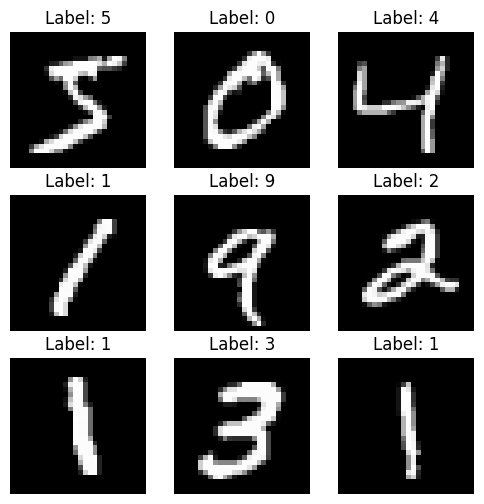

In [ ]:
plt.figure(figsize=(6,6))
for i in range(9) :
  plt.subplot(3,3,i+1)
  plt.imshow(x_train[i], cmap="gray")
  plt.title(f"Label: {y_train[i]}")
  plt.axis("off")

plt.show()

In [ ]:
x_train = x_train.astype("float32") /255.0
x_test = x_test.astype("float32") /255.0

x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print("New training shape:", x_train.shape)
print("New test shape:", x_test.shape)


New training shape: (60000, 784)
New test shape: (10000, 784)


In [ ]:
model = keras.Sequential ([
    layers.Dense(128, activation="relu",
input_shape=(784,)),
    layers.Dense(64,
activation="relu") ,
    layers.Dense(10,
activation="softmax")
])

#compile the model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=2
)

Epoch 1/5
1688/1688 - 10s - 6ms/step - accuracy: 0.9241 - loss: 0.2569 - val_accuracy: 0.9662 - val_loss: 0.1124
Epoch 2/5
1688/1688 - 9s - 5ms/step - accuracy: 0.9669 - loss: 0.1086 - val_accuracy: 0.9727 - val_loss: 0.0972
Epoch 3/5
1688/1688 - 8s - 5ms/step - accuracy: 0.9754 - loss: 0.0761 - val_accuracy: 0.9755 - val_loss: 0.0812
Epoch 4/5
1688/1688 - 10s - 6ms/step - accuracy: 0.9815 - loss: 0.0574 - val_accuracy: 0.9778 - val_loss: 0.0835
Epoch 5/5
1688/1688 - 10s - 6ms/step - accuracy: 0.9860 - loss: 0.0428 - val_accuracy: 0.9773 - val_loss: 0.0812


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.9255


In [ ]:
predictions =model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

print("predicted labels:", predicted_labels)
print("True labels:    ", y_test[:5])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
predicted labels: [7 2 1 0 4]
True labels:     [7 2 1 0 4]
